# Estatísticas do Corpus SIREVA-SUS

Gera tabelas e figuras para a seção *Corpus Statistics* do paper (STIL 2026).

**Input:** `data/silver/*.jsonl` (12 relatórios, 2013–2024)  
**Output:** figuras em `data/stats/figures/` + tabelas impressas

## 1. Setup

In [1]:
import json
import sys
from pathlib import Path
from collections import Counter, defaultdict

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

# Adiciona src/ ao path para importar config
sys.path.insert(0, str(Path(".").resolve() / "src"))
from config import DATA_SILVER, ENTITY_TYPES

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (13, 5)
plt.rcParams["font.size"] = 11

FIGURES_DIR = Path(".").resolve() / "data" / "stats" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

ENTITY_NAMES = [e["name"] for e in ENTITY_TYPES]
ENTITY_COLORS = [
    "#8e44ad", "#9b59b6", "#16a085", "#2980b9",
    "#7f8c8d", "#27ae60", "#d35400", "#e74c3c",
]

def read_jsonl(path):
    with path.open(encoding="utf-8") as f:
        return [json.loads(l) for l in f if l.strip()]

print("Setup OK")

Setup OK


## 2. Carregar dados silver

In [2]:
silver_files = sorted(DATA_SILVER.glob("*.jsonl"))
print(f"Relatórios encontrados: {len(silver_files)}")

all_sents = []
for sf in silver_files:
    recs = read_jsonl(sf)
    all_sents.extend(recs)

print(f"Total de sentenças: {len(all_sents):,}")
print(f"Exemplo de campos: {list(all_sents[0].keys())}")

Relatórios encontrados: 12
Total de sentenças: 3,343
Exemplo de campos: ['relatorio', 'pagina', 'sentenca_id', 'texto', 'tokens', 'bio_tags', 'spans']


## 2.1 Correções na anotação silver

- **SOROTIPO falso-positivo**: 23 spans onde o texto é a palavra "sorotipo" (cabeçalho de coluna) são removidos; apenas valores reais de sorotipo são mantidos.
- **FAIXA_ETARIA**: variações tipográficas (/, /) normalizadas para forma sem espaço.

In [ ]:
import re

_FA_NORM = re.compile(r"([<>≥≤])\s+")

def _fix_record(r):
    new_tags = list(r["bio_tags"])
    new_spans = []
    for sp in r.get("spans", []):
        if sp["tipo"] == "SOROTIPO" and sp["texto"].strip().lower() == "sorotipo":
            for i, (tok, tag) in enumerate(zip(r["tokens"], new_tags)):
                if tok.lower() == "sorotipo" and tag == "B-SOROTIPO":
                    new_tags[i] = "O"
        else:
            if sp["tipo"] == "FAIXA_ETARIA":
                sp = {**sp, "texto": _FA_NORM.sub(r"\1", sp["texto"])}
            new_spans.append(sp)
    r["bio_tags"] = new_tags
    r["spans"] = new_spans
    return r

all_sents = [_fix_record(r) for r in all_sents]

n_sorotipo = sum(1 for r in all_sents for t in r["bio_tags"] if t == "B-SOROTIPO")
fa_unique  = sorted({sp["texto"] for r in all_sents for sp in r.get("spans", []) if sp["tipo"] == "FAIXA_ETARIA"})
print(f"SOROTIPO após correção: {n_sorotipo} ocorrência(s) válida(s) (23 falsos positivos removidos)")
print(f"FAIXA_ETARIA variantes únicas: {fa_unique}")

## 3. Estatísticas gerais do corpus

In [3]:
total_sents  = len(all_sents)
total_tokens = sum(len(r["tokens"]) for r in all_sents)

# Contagem de entidades (pelo prefixo B-)
total_ents   = sum(1 for r in all_sents for t in r["bio_tags"] if t.startswith("B-"))
sents_w_ent  = sum(1 for r in all_sents if any(t != "O" for t in r["bio_tags"]))
sents_no_ent = total_sents - sents_w_ent

token_lens = [len(r["tokens"]) for r in all_sents]

print("=" * 45)
print("ESTATÍSTICAS GERAIS DO CORPUS SIREVA-SUS")
print("=" * 45)
print(f"Relatórios (anos):          {len(silver_files):>8}")
print(f"Total de sentenças:         {total_sents:>8,}")
print(f"Total de tokens:            {total_tokens:>8,}")
print(f"Total de entidades (silver):{total_ents:>8,}")
print(f"Sentenças com entidade:     {sents_w_ent:>8,}  ({sents_w_ent/total_sents*100:.1f}%)")
print(f"Sentenças sem entidade:     {sents_no_ent:>8,}  ({sents_no_ent/total_sents*100:.1f}%)")
print(f"Média tokens/sentença:      {np.mean(token_lens):>8.1f}")
print(f"Mediana tokens/sentença:    {np.median(token_lens):>8.1f}")
print(f"Desvio padrão tokens:       {np.std(token_lens):>8.1f}")
print(f"Min / Max tokens:           {min(token_lens):>4} / {max(token_lens):>4}")

ESTATÍSTICAS GERAIS DO CORPUS SIREVA-SUS
Relatórios (anos):                12
Total de sentenças:            3,343
Total de tokens:              19,748
Total de entidades (silver):   1,139
Sentenças com entidade:          772  (23.1%)
Sentenças sem entidade:        2,571  (76.9%)
Média tokens/sentença:           5.9
Mediana tokens/sentença:         4.0
Desvio padrão tokens:            6.1
Min / Max tokens:              1 /   72


## 4. Estatísticas por relatório (ano)

In [4]:
rows = []
for sf in silver_files:
    recs = read_jsonl(sf)
    year = sf.stem.replace("sireva_", "")
    n_sents  = len(recs)
    n_tokens = sum(len(r["tokens"]) for r in recs)
    n_ents   = sum(1 for r in recs for t in r["bio_tags"] if t.startswith("B-"))
    n_w_ent  = sum(1 for r in recs if any(t != "O" for t in r["bio_tags"]))
    rows.append({
        "Ano":        year,
        "Sentenças":  n_sents,
        "Tokens":     n_tokens,
        "Entidades":  n_ents,
        "c/Entidade": n_w_ent,
        "% c/Ent":    round(n_w_ent / n_sents * 100, 1),
        "Ent/Sent":   round(n_ents / n_sents, 2),
    })

df_year = pd.DataFrame(rows)
print(df_year.to_string(index=False))
print(f"\nTOTAL  {df_year['Sentenças'].sum():>6,}  {df_year['Tokens'].sum():>8,}  {df_year['Entidades'].sum():>8,}")

 Ano  Sentenças  Tokens  Entidades  c/Entidade  % c/Ent  Ent/Sent
2013        257    1422         84          57     22.2      0.33
2014        249    1404         75          52     20.9      0.30
2015        255    1446         79          53     20.8      0.31
2016        266    1507         86          61     22.9      0.32
2017        230    1311         70          52     22.6      0.30
2018        238    1378         69          48     20.2      0.29
2019        243    1528         79          55     22.6      0.33
2020        274    1665        104          69     25.2      0.38
2021        281    1683        100          66     23.5      0.36
2022        295    1728        106          67     22.7      0.36
2023        385    2358        155         107     27.8      0.40
2024        370    2318        132          85     23.0      0.36

TOTAL   3,343    19,748     1,139


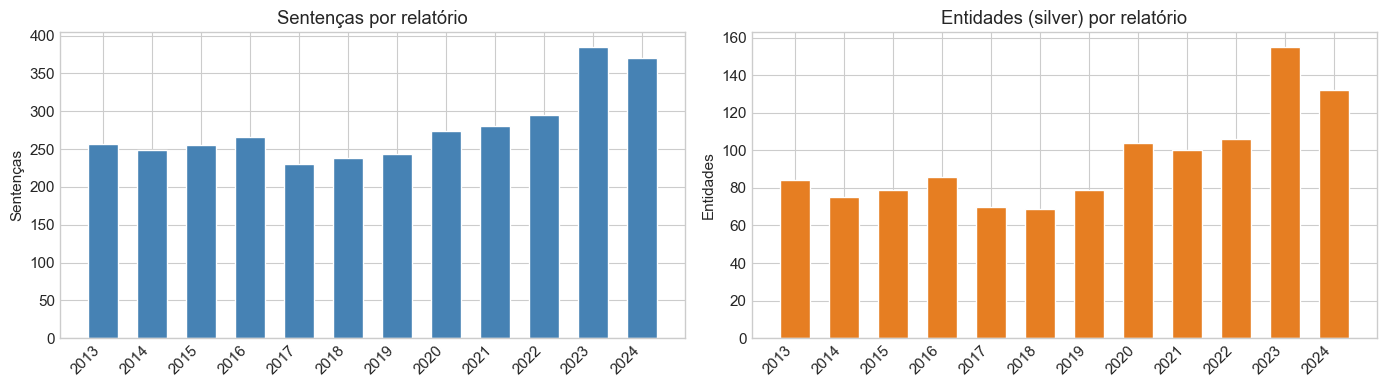

Salvo: C:\Users\chris\OneDrive\Documentos\Projetos\SIREVA-SUS-Corpus\data\stats\figures\sents_ents_per_year.pdf


In [5]:
anos = df_year["Ano"].tolist()
x = np.arange(len(anos))
width = 0.4

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Sentenças por ano
axes[0].bar(x, df_year["Sentenças"], width=0.6, color="steelblue", edgecolor="white")
axes[0].set_xticks(x)
axes[0].set_xticklabels(anos, rotation=45, ha="right")
axes[0].set_title("Sentenças por relatório")
axes[0].set_ylabel("Sentenças")
axes[0].yaxis.set_major_locator(mticker.MaxNLocator(integer=True))

# Entidades por ano
axes[1].bar(x, df_year["Entidades"], width=0.6, color="#e67e22", edgecolor="white")
axes[1].set_xticks(x)
axes[1].set_xticklabels(anos, rotation=45, ha="right")
axes[1].set_title("Entidades (silver) por relatório")
axes[1].set_ylabel("Entidades")
axes[1].yaxis.set_major_locator(mticker.MaxNLocator(integer=True))

plt.tight_layout()
plt.savefig(FIGURES_DIR / "sents_ents_per_year.pdf", bbox_inches="tight")
plt.show()
print(f"Salvo: {FIGURES_DIR / 'sents_ents_per_year.pdf'}")

## 5. Distribuição de entidades por categoria

In [6]:
ent_counts = Counter(
    tag[2:] for r in all_sents for tag in r["bio_tags"] if tag.startswith("B-")
)

df_ent = pd.DataFrame(
    [(e, ent_counts.get(e, 0), round(ent_counts.get(e, 0) / total_ents * 100, 1))
     for e in ENTITY_NAMES],
    columns=["Categoria", "Ocorrências", "%"]
).sort_values("Ocorrências", ascending=False).reset_index(drop=True)

print(df_ent.to_string(index=False))
print(f"\nTotal: {df_ent['Ocorrências'].sum():,} entidades")

           Categoria  Ocorrências    %
               LOCAL          592 52.0
            PATOGENO          379 33.3
        FAIXA_ETARIA           57  5.0
          METODO_LAB           54  4.7
            SOROTIPO           24  2.1
    PERIODO_TEMPORAL           18  1.6
MANIFESTACAO_CLINICA           15  1.3
         METRICA_EPI            0  0.0

Total: 1,139 entidades


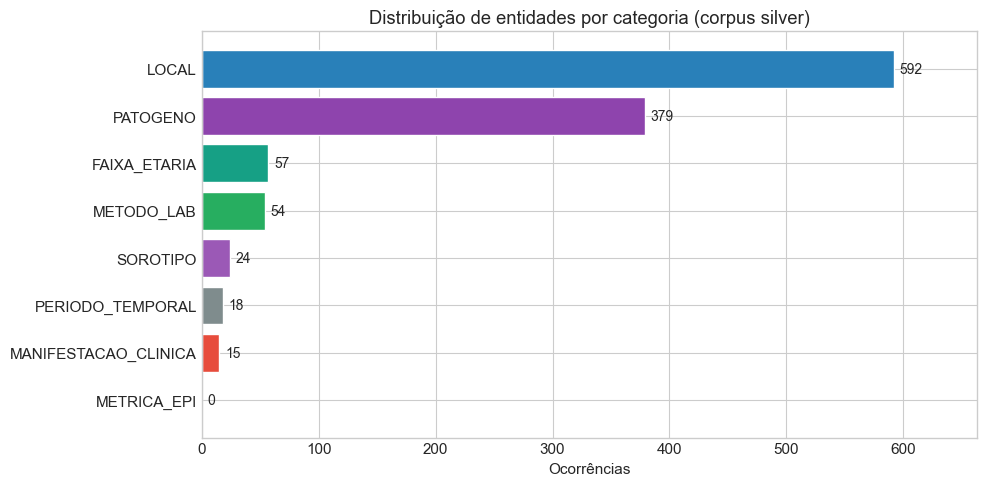

Salvo: C:\Users\chris\OneDrive\Documentos\Projetos\SIREVA-SUS-Corpus\data\stats\figures\entity_distribution.pdf


In [7]:
df_plot = df_ent.sort_values("Ocorrências", ascending=True)
colors = [ENTITY_COLORS[ENTITY_NAMES.index(e)] for e in df_plot["Categoria"]]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(df_plot["Categoria"], df_plot["Ocorrências"], color=colors, edgecolor="white")

for bar, val in zip(bars, df_plot["Ocorrências"]):
    ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height() / 2,
            f"{val:,}", va="center", fontsize=10)

ax.set_title("Distribuição de entidades por categoria (corpus silver)")
ax.set_xlabel("Ocorrências")
ax.margins(x=0.12)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "entity_distribution.pdf", bbox_inches="tight")
plt.show()
print(f"Salvo: {FIGURES_DIR / 'entity_distribution.pdf'}")

## 6. Evolução temporal das entidades (2013–2024)

In [8]:
# Matriz: ano x categoria
year_ent = defaultdict(Counter)
for r in all_sents:
    year = r["relatorio"].replace("sireva_", "")
    for tag in r["bio_tags"]:
        if tag.startswith("B-"):
            year_ent[year][tag[2:]] += 1

anos_sorted = sorted(year_ent.keys())
df_temporal = pd.DataFrame(
    {ano: {e: year_ent[ano].get(e, 0) for e in ENTITY_NAMES} for ano in anos_sorted}
).T
df_temporal.index.name = "Ano"

print(df_temporal.to_string())

      PATOGENO  SOROTIPO  FAIXA_ETARIA  LOCAL  PERIODO_TEMPORAL  METODO_LAB  METRICA_EPI  MANIFESTACAO_CLINICA
Ano                                                                                                           
2013        27         3             4     45                 2           2            0                     1
2014        24         2             4     38                 3           2            0                     2
2015        27         3             3     42                 2           2            0                     0
2016        24         2             4     54                 2           0            0                     0
2017        25         1             4     37                 2           1            0                     0
2018        25         1             4     39                 0           0            0                     0
2019        26         1             5     46                 0           1            0                     0
2

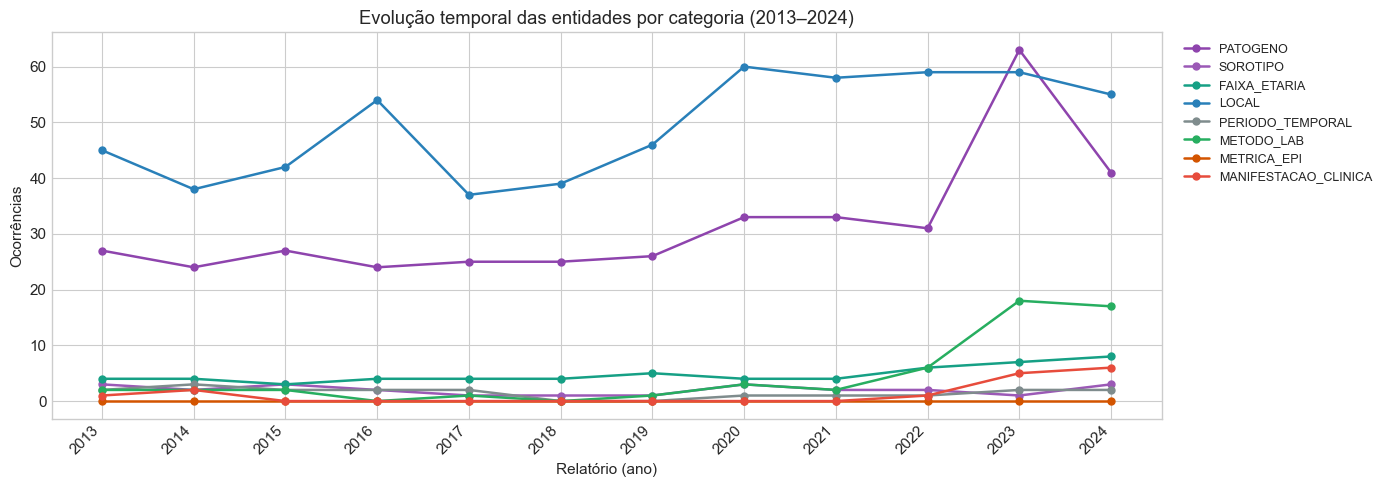

Salvo: C:\Users\chris\OneDrive\Documentos\Projetos\SIREVA-SUS-Corpus\data\stats\figures\temporal_evolution.pdf


In [9]:
fig, ax = plt.subplots(figsize=(14, 5))

for ent, color in zip(ENTITY_NAMES, ENTITY_COLORS):
    ax.plot(df_temporal.index, df_temporal[ent], marker="o", label=ent,
            color=color, linewidth=1.8, markersize=5)

ax.set_title("Evolução temporal das entidades por categoria (2013–2024)")
ax.set_xlabel("Relatório (ano)")
ax.set_ylabel("Ocorrências")
ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=9)
ax.set_xticks(range(len(df_temporal.index)))
ax.set_xticklabels(df_temporal.index, rotation=45, ha="right")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "temporal_evolution.pdf", bbox_inches="tight")
plt.show()
print(f"Salvo: {FIGURES_DIR / 'temporal_evolution.pdf'}")

## 7. Menções mais frequentes por categoria

In [10]:
TOP_K = 10

# Agrupa spans por tipo
spans_by_type = defaultdict(list)
for r in all_sents:
    for sp in r.get("spans", []):
        spans_by_type[sp["tipo"]].append(sp["texto"].strip().lower())

print(f"Top {TOP_K} menções por categoria:\n")
for ent in ENTITY_NAMES:
    counter = Counter(spans_by_type[ent])
    top = counter.most_common(TOP_K)
    if not top:
        print(f"[{ent}] — sem ocorrências")
        continue
    print(f"[{ent}]")
    for mention, count in top:
        print(f"  {count:>5}  {mention}")
    print()

Top 10 menções por categoria:

[PATOGENO]
    168  streptococcus pneumoniae
    107  haemophilus influenzae
    100  neisseria meningitidis
      2  n meningitidis
      2  s. pneumoniae
      1  haemophilusinfluenzae

[SOROTIPO]
     23  sorotipo
      1  sorotipo 19a

[FAIXA_ETARIA]
     22  ≥ 5 anos
     15  <5 anos
     11  < 5 anos
      7  ≥5 anos
      2  24-59 meses

[LOCAL]
     47  sp
     46  são paulo
     41  brasil
     30  instituto adolfo lutz
     17  ministério da saúde
     16  brasília
     12  estados brasileiros
     12  espírito santo
     12  mato grosso do sul
     12  minas gerais

[PERIODO_TEMPORAL]
      3  2014
      2  2013
      2  2015
      2  2016
      2  2017
      2  2023
      2  2024
      1  2020
      1  2021
      1  2022

[METODO_LAB]
     17  diagnóstico
     15  pcr em tempo real
     11  cultura
      5  pcr convencional
      4  pcr tempo real
      4  sorotipagem
      1  testes de sensibilidade
      1  tempo real

[METRICA_EPI] — sem oc

## 8. Distribuição de comprimento das sentenças

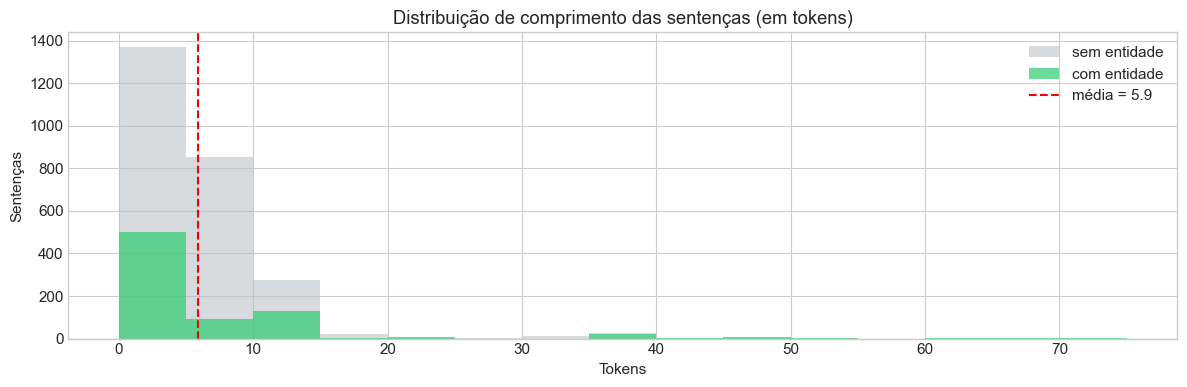

Salvo: C:\Users\chris\OneDrive\Documentos\Projetos\SIREVA-SUS-Corpus\data\stats\figures\sentence_length.pdf


In [11]:
lens_w  = [len(r["tokens"]) for r in all_sents if any(t != "O" for t in r["bio_tags"])]
lens_wo = [len(r["tokens"]) for r in all_sents if all(t == "O" for t in r["bio_tags"])]

fig, ax = plt.subplots(figsize=(12, 4))
bins = range(0, max(token_lens) + 5, 5)
ax.hist(lens_wo, bins=bins, alpha=0.6, label="sem entidade", color="#bdc3c7")
ax.hist(lens_w,  bins=bins, alpha=0.7, label="com entidade", color="#2ecc71")
ax.axvline(np.mean(token_lens), color="red", linestyle="--",
           label=f"média = {np.mean(token_lens):.1f}")
ax.set_title("Distribuição de comprimento das sentenças (em tokens)")
ax.set_xlabel("Tokens")
ax.set_ylabel("Sentenças")
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "sentence_length.pdf", bbox_inches="tight")
plt.show()
print(f"Salvo: {FIGURES_DIR / 'sentence_length.pdf'}")

## 9. Co-ocorrência de categorias na mesma sentença

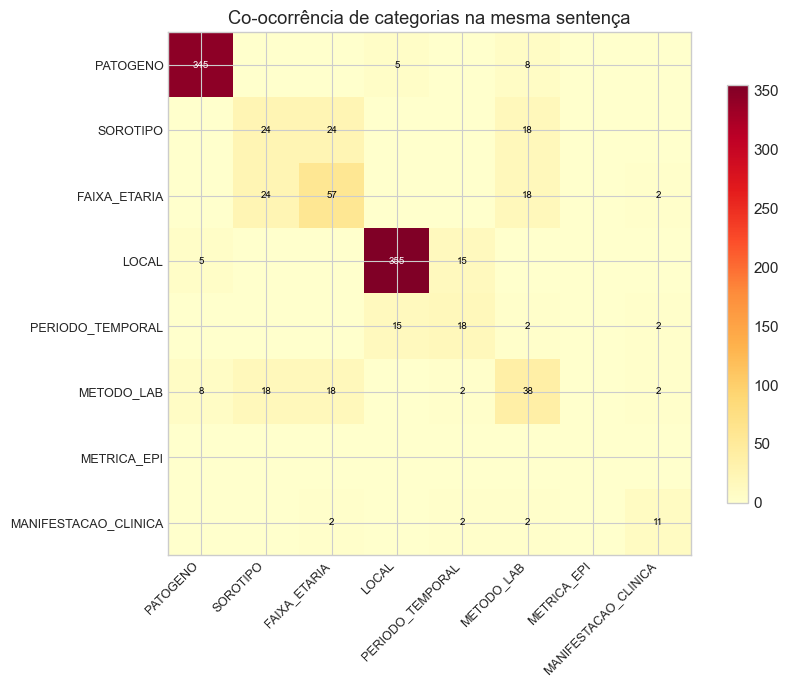

Salvo: C:\Users\chris\OneDrive\Documentos\Projetos\SIREVA-SUS-Corpus\data\stats\figures\cooccurrence_matrix.pdf


In [12]:
# Matriz de co-ocorrência (entidade A e B na mesma sentença)
cooc = pd.DataFrame(0, index=ENTITY_NAMES, columns=ENTITY_NAMES)

for r in all_sents:
    present = set(tag[2:] for tag in r["bio_tags"] if tag.startswith("B-"))
    ents_list = sorted(present)
    for i, a in enumerate(ents_list):
        for b in ents_list[i:]:
            cooc.loc[a, b] += 1
            if a != b:
                cooc.loc[b, a] += 1

fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(cooc.values, cmap="YlOrRd")
plt.colorbar(im, ax=ax, shrink=0.8)
ax.set_xticks(range(len(ENTITY_NAMES)))
ax.set_yticks(range(len(ENTITY_NAMES)))
ax.set_xticklabels(ENTITY_NAMES, rotation=45, ha="right", fontsize=9)
ax.set_yticklabels(ENTITY_NAMES, fontsize=9)
ax.set_title("Co-ocorrência de categorias na mesma sentença")

# Anota valores nas células
for i in range(len(ENTITY_NAMES)):
    for j in range(len(ENTITY_NAMES)):
        val = cooc.iloc[i, j]
        if val > 0:
            ax.text(j, i, str(val), ha="center", va="center",
                    fontsize=7, color="black" if val < cooc.values.max() * 0.6 else "white")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "cooccurrence_matrix.pdf", bbox_inches="tight")
plt.show()
print(f"Salvo: {FIGURES_DIR / 'cooccurrence_matrix.pdf'}")

## 10. Resumo — tabela para o paper

In [13]:
print("\nTABELA RESUMO (LaTeX)\n")
print("\\begin{table}[h]")
print("\\centering")
print("\\begin{tabular}{lr}")
print("\\toprule")
print("Estatística & Valor \\\\")
print("\\midrule")
print(f"Relatórios (anos) & {len(silver_files)} \\\\")
print(f"Sentenças (total) & {total_sents:,} \\\\")
print(f"Tokens (total) & {total_tokens:,} \\\\")
print(f"Entidades anotadas (silver) & {total_ents:,} \\\\")
print(f"Sentenças com entidade & {sents_w_ent:,} ({sents_w_ent/total_sents*100:.1f}\\%) \\\\")
print(f"Média tokens/sentença & {np.mean(token_lens):.1f} \\\\")
print(f"Categorias NER & {len(ENTITY_NAMES)} \\\\")
print("\\bottomrule")
print("\\end{tabular}")
print("\\caption{Estatísticas do corpus SIREVA-SUS (anotação silver, 2013--2024).}")
print("\\label{tab:corpus-stats}")
print("\\end{table}")

print("\n---")
print(f"Figuras salvas em: {FIGURES_DIR}")


TABELA RESUMO (LaTeX)

\begin{table}[h]
\centering
\begin{tabular}{lr}
\toprule
Estatística & Valor \\
\midrule
Relatórios (anos) & 12 \\
Sentenças (total) & 3,343 \\
Tokens (total) & 19,748 \\
Entidades anotadas (silver) & 1,139 \\
Sentenças com entidade & 772 (23.1\%) \\
Média tokens/sentença & 5.9 \\
Categorias NER & 8 \\
\bottomrule
\end{tabular}
\caption{Estatísticas do corpus SIREVA-SUS (anotação silver, 2013--2024).}
\label{tab:corpus-stats}
\end{table}

---
Figuras salvas em: C:\Users\chris\OneDrive\Documentos\Projetos\SIREVA-SUS-Corpus\data\stats\figures


## 11. Estatísticas dos Boletins Epidemiológicos

Análise dos novos documentos adicionados ao corpus: boletins eletrônicos, boletins epidemiológicos e informes de meningite.

In [ ]:
# Carrega apenas os boletins (exclui sireva_*)
BOLETIM_SLUGS = {
    "boletim_eletronico_ano08_n17": "Bol. Eletrônico Ano08 nº17",
    "boletim_eletronico_ano08_n18": "Bol. Eletrônico Ano08 nº18",
    "boletim_eletronico_ano10_n03": "Bol. Eletrônico Ano10 nº03",
    "boletim_epidemiologico_nesp":  "Bol. Epi. Nº Especial",
    "boletim_epidemiologico_v47_n29": "Bol. Epi. V47 nº29",
    "boletim_epidemiologico_v50_n03": "Bol. Epi. V50 nº03",
    "boletim_epidemiologico_n25":   "Bol. Epi. nº25",
    "boletim_epidemiologico_n38":   "Bol. Epi. nº38",
    "informe_meningite_ed01":       "Informe Meningite Ed.1",
    "informe_meningite_ed02":       "Informe Meningite Ed.2",
}

boletim_files = [DATA_SILVER / f"{slug}.jsonl" for slug in BOLETIM_SLUGS]
boletim_files_found = [p for p in boletim_files if p.exists()]

if not boletim_files_found:
    print("Nenhum arquivo de boletim encontrado em data/silver/. Execute process_boletins.py primeiro.")
else:
    print(f"Boletins encontrados: {len(boletim_files_found)}/{len(boletim_files)}")

boletim_sents = []
for p in boletim_files_found:
    boletim_sents.extend(read_jsonl(p))

print(f"Total de sentenças (boletins): {len(boletim_sents):,}")

In [ ]:
# Estatísticas por documento
rows_bol = []
for slug, label in BOLETIM_SLUGS.items():
    path = DATA_SILVER / f"{slug}.jsonl"
    if not path.exists():
        continue
    recs = read_jsonl(path)
    n_sents  = len(recs)
    n_tokens = sum(len(r["tokens"]) for r in recs)
    n_ents   = sum(1 for r in recs for t in r["bio_tags"] if t.startswith("B-"))
    n_w_ent  = sum(1 for r in recs if any(t != "O" for t in r["bio_tags"]))
    rows_bol.append({
        "Documento":   label,
        "Sentenças":   n_sents,
        "Tokens":      n_tokens,
        "Entidades":   n_ents,
        "c/Entidade":  n_w_ent,
        "% c/Ent":     round(n_w_ent / n_sents * 100, 1) if n_sents else 0,
        "Ent/Sent":    round(n_ents / n_sents, 2) if n_sents else 0,
    })

df_bol = pd.DataFrame(rows_bol)
print(df_bol.to_string(index=False))
print(f"\nTOTAL  {df_bol['Sentenças'].sum():>6,}  tokens: {df_bol['Tokens'].sum():>8,}  entidades: {df_bol['Entidades'].sum():>6,}")

In [ ]:
# Distribuição de entidades nos boletins
bol_ent_counts = Counter(
    tag[2:] for r in boletim_sents for tag in r["bio_tags"] if tag.startswith("B-")
)
bol_total_ents = sum(bol_ent_counts.values()) or 1

df_bol_ent = pd.DataFrame(
    [(e, bol_ent_counts.get(e, 0), round(bol_ent_counts.get(e, 0) / bol_total_ents * 100, 1))
     for e in ENTITY_NAMES],
    columns=["Categoria", "Ocorrências", "%"]
).sort_values("Ocorrências", ascending=False).reset_index(drop=True)

print(df_bol_ent.to_string(index=False))
print(f"\nTotal: {df_bol_ent['Ocorrências'].sum():,} entidades")

In [ ]:
# Comparação SIREVA vs Boletins — distribuição de entidades (%)
sireva_ent_counts = Counter(
    tag[2:] for r in all_sents
    if r["relatorio"].startswith("sireva")
    for tag in r["bio_tags"] if tag.startswith("B-")
)
sireva_total = sum(sireva_ent_counts.values()) or 1

pct_sireva  = [sireva_ent_counts.get(e, 0) / sireva_total * 100 for e in ENTITY_NAMES]
pct_boletim = [bol_ent_counts.get(e, 0) / bol_total_ents * 100 for e in ENTITY_NAMES]

x = np.arange(len(ENTITY_NAMES))
width = 0.38

fig, ax = plt.subplots(figsize=(13, 5))
ax.bar(x - width / 2, pct_sireva,  width, label="SIREVA (2013–2024)", color="steelblue",  edgecolor="white")
ax.bar(x + width / 2, pct_boletim, width, label="Boletins",           color="#e67e22", edgecolor="white")

ax.set_xticks(x)
ax.set_xticklabels(ENTITY_NAMES, rotation=30, ha="right", fontsize=10)
ax.set_ylabel("% do total de entidades")
ax.set_title("Distribuição de entidades: SIREVA vs Boletins (silver)")
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "entity_comparison_sireva_boletins.pdf", bbox_inches="tight")
plt.show()
print(f"Salvo: {FIGURES_DIR / 'entity_comparison_sireva_boletins.pdf'}")

In [ ]:
# Top-10 menções por categoria nos boletins
bol_spans_by_type = defaultdict(list)
for r in boletim_sents:
    for sp in r.get("spans", []):
        bol_spans_by_type[sp["tipo"]].append(sp["texto"].strip().lower())

print(f"Top 10 menções por categoria (boletins):\n")
for ent in ENTITY_NAMES:
    counter = Counter(bol_spans_by_type[ent])
    top = counter.most_common(10)
    if not top:
        print(f"[{ent}] — sem ocorrências")
        continue
    print(f"[{ent}]")
    for mention, count in top:
        print(f"  {count:>5}  {mention}")
    print()